# Photonic FBQC on ITensor — the PsiQuantum **6-ring** fusion network

This notebook builds a memory experiment as an actual **fusion network of 6-ring resource states**, under three hard
rules, enforced throughout and verified live:

1. **After resource-state preparation, the only entangling operation is a type-II fusion** — a
   beam-splitter Bell measurement. No CZ is ever applied between separately-created photons; CZ
   appears only inside the clearly-boxed resource constructors (what the source delivers).
2. **Everything is nodes and leaves of ring geometry.** Every data worldline threads one 6-ring per
   time step: it *arrives* by the fusion at the ring's $z^-$ photon, *leaves* by the fusion at
   $z^+$, and the ring's spatial photons fuse with neighbouring rings — those fusions' outcomes
   *are* the check edges. Leaves are the photons consumed in fusions; nodes are measured in the
   $X$ pattern; boundary spares are pruned by single-photon $Z$ measurements.
3. **There is no check stage and no forward stage.** A slab is one loop — *deliver each ring, fuse
   it in* — and the classical record it leaves behind contains the syndrome, the transport frame,
   and the logical readout, all as GF(2) parities of the same fusion outcomes.

Two engines run everything: the exact **ITensor MPS** (ground truth — every headline result is
executed on it), and a **stabilizer tableau** twin (`chp_tableau.jl`) for the wide sweeps — the
whole network is Clifford, so hundreds of runs take seconds.

## 0 · Load the engines

In [ ]:
include("./functions/photonic_mps.jl")      # dynamic-site ITensor MPS + §J ring section
include("./functions/chp_tableau.jl")       # stabilizer-tableau twin + GF(2) analysis tools
include("./functions/ring_diagrams.jl")     # SVG diagrams, generated from the same pairing tables
using Random; Random.seed!(2024)
CUTOFF[] = 1e-12                # SVD truncation — we want exactness on this small code
PEAK = Ref(0); track!(r) = (PEAK[] = max(PEAK[], length(r)))
println("engines loaded · CUTOFF = ", CUTOFF[])

engines loaded · CUTOFF = 1.0e-12

## 1 · The 6-ring resource state

The PsiQuantum resource state is the **6-ring**: six photons whose CZ edges form a cycle,
generated near-deterministically at the source — so we *prepare* it directly (a resource box) and
do **not** simulate its creation. Its graph stabilizers are $K_i = X_i Z_{i-1} Z_{i+1}$ (cyclic).

In [2]:
let
    r = Reg(); labs = [Symbol("p$i") for i in 1:6]
    ring_resource_state!(r, labs)                     # |+>^6 + six ring CZs — made at the source
    println("prepared a 6-ring on ", length(r), " photons\n")
    for i in 1:6
        ev = expect_pauli(r, Dict(labs[i] => 'X', labs[ring_prev(i,6)] => 'Z', labs[ring_next(i,6)] => 'Z'))
        println("  K_$i = X_$i Z_$(ring_prev(i,6)) Z_$(ring_next(i,6))   =>   <K_$i> = ", round(ev, digits=10))
    end
end

prepared a 6-ring on 6

 photons

  K_1 = X_1 Z_6 Z_2   =>   <K_1> = 1.0


  K_2 = X_2 Z_1 Z_3   =>   <K_2> = 1.0
  K_3 = X_3 Z_2 Z_4   =>   <K_3> = 1.0
  K_4 = X_4 Z_3 Z_5   =>   <K_4> = 1.0
  K_5 = X_5 Z_4 Z_6   =>   <K_5> = 1.0
  K_6 = X_6 Z_5 Z_1   =>   <K_6> = 1.0


## 2 · Every fusion is a beam-splitter Bell measurement — shown

A type-II fusion is physically a **beam-splitter Bell-state measurement**: the click pattern
returns the two commuting parities $X_1X_2$ and $Z_1Z_2$, and both photons are absorbed. In the
engine it is realised by the exact Bell-analyzer circuit (CNOT + two local readouts — verified
identical to the joint-projector route). `SHOW_FUSIONS[]=true` prints each fusion's Bell outcome;
`FUSES` counts every one we pay for.

In [3]:
let
    SHOW_FUSIONS[] = true; reset_fuses!()
    r = Reg(); for q in [:A, :la, :B, :lb]; addphoton!(r, q); end
    cz!(r, :A, :la); cz!(r, :B, :lb)                 # (resource box: two node+leaf pairs)
    println("fusing the two leaves la ⋈ lb:")
    (mx, mz) = fuse!(r, :la, :lb)
    println("\nreturned (mx, mz) = (", mx, ", ", mz, ")   ·   fusions paid = ", FUSES[])
    SHOW_FUSIONS[] = false
end

fusing the two leaves la ⋈ lb:


    beam-splitter fusion la

⋈lb  →  Bell outcome Ψ⁺   (X₁X₂=1, Z₁Z₂=-1)

returned (mx, mz) = (0, 1)   ·   fusions paid = 1


false

## 3 · One fusion = a primal edge, a dual edge, *and* a step in time

A leaf $\ell$ on node $A$ pins $X_\ell \equiv Z_A$ (the edge stabilizer). Fusing a leaf of $A$
with a leaf of $B$ therefore reads $X_\ell^AX_\ell^B \equiv Z_AZ_B$ — a **primal** ($Z$-check)
edge — and $Z_\ell^AZ_\ell^B \equiv X_AX_B$ dressed by the nodes' other neighbours — a **dual**
($X$-check) edge. And the same fusion Bell-merges $A$ with $B$: if $B$ is a next-layer photon, it
*carries the worldline forward*. Verified exactly on the MPS:

In [4]:
let  # leg 1 — fusion XX == Z_A Z_B, every trial
    ok = true
    for t in 1:200
        r = Reg(); for q in [:A, :B, :la, :lb]; addphoton!(r, q); end
        cz!(r, :A, :la); cz!(r, :B, :lb); cz!(r, :A, :B)      # (resource box)
        (mx, _) = fuse!(r, :la, :lb)
        ok &= isapprox((-1)^mx, expect_pauli(r, Dict(:A=>'Z', :B=>'Z')); atol=1e-9)
    end
    println("leg 1 — fusion XX == Z_A Z_B (primal edge), all 200 trials: ", ok)
end
let  # leg 2 — the same fusion forwards a worldline
    okf = true
    for t in 1:100
        r = Reg()
        addphoton!(r, :A; state=:zero); addphoton!(r, :la); cz!(r, :A, :la)   # (resource box)
        addphoton!(r, :B; state=:plus); addphoton!(r, :lb); cz!(r, :B, :lb)
        fuse!(r, :la, :lb); measX!(r, :A)
        okf &= isapprox(abs(expect_pauli(r, Dict(:B=>'Z'))), 1; atol=1e-9)
    end
    println("leg 2 — same fusion forwards the Z-worldline, all 100 trials: ", okf)
end

leg 1 — fusion XX == Z_A Z_B (primal edge), all 200 trials: true


leg 2 — same fusion forwards the Z-worldline, all 100 trials: 

true


## 4 · Ring anatomy — what each photon of the ring *is*

The interleaving paper slices the 6-ring network into time slices: **each ring becomes a vertex of
a cubic fusion lattice with its six photons labelled $x^\pm, y^\pm, z^\pm$** — one fusion per
photon; $z^\pm$ are the two *temporal* fusions, $x^\pm,y^\pm$ the four *spatial* ones. The
diagram below shows one of our rings, photon by photon (every coloured disc is a photon **node**;
every small white circle is that node's **leaf** — the extra photon, grown at the source, that a
fusion actually consumes so the node itself survives to be pattern-measured):

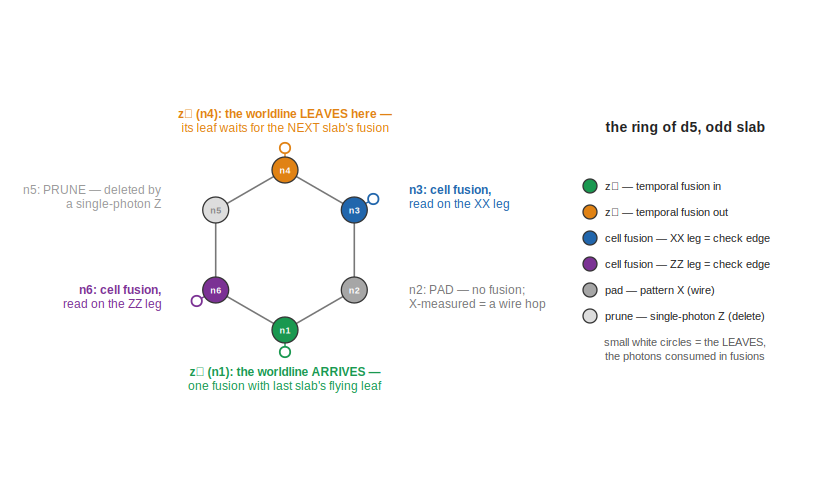

In [5]:
show_svg(diagramA())

**Why two photons for the spatial fusions but one for time?** Count what one ring must do
in its one slab of life:

* **time in** — one fusion at $z^-$ (with the flying leaf of last slab's ring): *this* slab pays it;
* **time out** — the $z^+$ photon just *waits*: its fusion is the $z^-$ fusion of the **next**
  slab's ring. So each ring pays **one** temporal fusion, and each worldline crosses one fusion
  per slab boundary — the temporal photons come in in/out pairs but the fusions are shared;
* **space** — the qubit belongs to (up to) **two same-type cells per slab** — e.g. `d5` sits in
  both `Z1245` and `Z5689` — and *each cell needs its own fusion with a different neighbour*, so
  two spatial photons ($n3$ and $n6$) are consumed. In the full-distance bulk of the papers a
  qubit borders **four** same-type cells per slice pair, which is exactly why the bulk ring fuses
  all four of its spatial photons $x^\pm,y^\pm$.

**These slot roles are not assumptions — they can be read off the state.** The tableau twin runs a
Choi probe: a reference qubit $R$ is maximally entangled with the incoming worldline, the ring is
fused in and pattern-measured, and the reduced stabilizer group on $\{R,\ \text{slot leaf},\
z^+\}$ *states* which operator of the input each slot's fusion would measure:

In [6]:
# Choi probe of one leafed ring (tableau): R ⨝ worldline; temporal fusion; spine pattern;
# one slot's leaf kept unfused; spares pruned. reduced_group tells us what that leaf carries.
function probe_slot(k::Int)
    t = Tab(12)
    R, W, LW = 1, 2, 3; nq(kk) = 3 + kk; L1, Lk, L4 = 10, 11, 12
    h!(t, R); cnot!(t, R, W)                       # R–W Bell: the input leg of the Choi state
    h!(t, LW); cz!(t, W, LW)                       # (resource box: leaf on the worldline)
    for kk in 1:6; h!(t, nq(kk)); end
    for kk in 1:6; cz!(t, nq(kk), nq(kk == 6 ? 1 : kk+1)); end
    h!(t, L1); cz!(t, nq(1), L1); h!(t, Lk); cz!(t, nq(k), Lk); h!(t, L4); cz!(t, nq(4), L4)
    cnot!(t, LW, L1); measure_x!(t, LW); measure_z!(t, L1)     # temporal fusion (Bell analyzer)
    measure_x!(t, W); measure_x!(t, nq(1))                     # pattern
    for kk in (2,3,5,6)
        (kk == 2 || kk == 3 || kk == k) ? measure_x!(t, nq(kk)) : measure_z!(t, nq(kk))
    end
    grp = reduced_group(t, [R, Lk, L4])
    println("  slot n$k:  ", join([(sg > 0 ? "+" : "-") * ps for (ps, sg) in grp], "   "),
            "      (order: R, leaf, z+)")
end
println("what does each slot's fusion read?  (X_leaf ≡ ... of the input R)")
for k in (2,3,5,6); probe_slot(k); end
println("""
=> arm-1 slots: n3's XX-leg reads Z_in (a primal edge); n2's XX-leg reads X_in (dual);
   arm-2 slots: n6's ZZ-leg reads Z_in; n5's ZZ-leg reads X_in.
   One fusion, two legs, two syndrome graphs — the ∏(XX)·∏(ZZ) of the FBQC paper.""")

what does each slot's fusion read?  (X_leaf ≡ ... of the input R)


  slot n2:  +XXI   +XIX

      (order: R, leaf, z+)
  slot n3:  +ZXI   -XZX      (order: R, leaf, z+)
  slot n5:  +XZI   -XIX      (order: R, leaf, z+)
  slot n6:  -ZZI   -XXX      (order: R, leaf, z+)
=> arm-1 slots: n3's XX-leg reads Z_in (a primal edge); n2's XX-leg reads X_in (dual);
   arm-2 slots: n6's ZZ-leg reads Z_in; n5's ZZ-leg reads X_in.
   One fusion, two legs, two syndrome graphs — the ∏(XX)·∏(ZZ) of the FBQC paper.


### The $d{=}3$ fit, and the primal/dual rhythm

Per slab, each data qubit needs **one spatial fusion per cell it belongs to, of one type**: the
rotated $d{=}3$ code has every qubit in $\le 2$ $Z$-cells and $\le 2$ $X$-cells, so its ring's two
$Z$-reading slots ($n3$, $n6$) cover the $Z$-cells and — by the RHG half-layer offset — the *same
slots at the next slab* cover the $X$-cells: **each slab applies one Hadamard to every worldline**
(a cluster-wire step), so the *identical physical fusion pattern* reads the code's $Z$-cells on
odd slabs and its $X$-cells on even slabs. Primal and dual cells live on alternating layers — the
foliation rhythm of the RHG lattice, appearing here as a *frame*, not extra hardware.

Spares: an unused arm-1 slot is **padded** (pattern-$X$, a wire hop — keeps the spine intact); an
unused arm-2 slot is **pruned** (single-photon $Z$ — the FBQC paper's boundary carving). One
subtlety we verified the hard way: a closed ring with *no* fusions decoheres the worldline (its
loop measures non-stabilizer information); the prune is what breaks boundary loops, and only the
fused network makes closed bulk rings safe. Ring geometry and code geometry are the same object.

In [7]:
# the spatial pairings: (cell, qubit_a, slot_a, qubit_b, slot_b) — same-slot pairs only;
# odd slabs read the Z-cells, even slabs the X-cells (the H-frame alternation)
const SPATIAL_ODD = [
    ("Z1245", 1,:n3, 2,:n3), ("Z1245", 4,:n3, 5,:n3),
    ("Z5689", 5,:n6, 6,:n6), ("Z5689", 8,:n3, 9,:n3),
    ("Z47",   4,:n6, 7,:n6),
    ("Z36",   3,:n3, 6,:n3),
]
const SPATIAL_EVEN = [
    ("X2356", 2,:n3, 3,:n3), ("X2356", 5,:n6, 6,:n6),
    ("X4578", 4,:n3, 5,:n3), ("X4578", 7,:n6, 8,:n6),
    ("X12",   1,:n6, 2,:n6),
    ("X89",   8,:n3, 9,:n3),
]
spatial(t) = isodd(t) ? SPATIAL_ODD : SPATIAL_EVEN
fused_slots(t, i) = [s for (_,a,sa,b,sb) in spatial(t) for (q,s) in ((a,sa),(b,sb)) if q == i]
pad_slots(t, i)   = [s for s in (:n2,:n3) if !(s in fused_slots(t, i))]
prune_slots(t, i) = [s for s in (:n5,:n6) if !(s in fused_slots(t, i))]
retire_after(t, a) = maximum(vcat([a], [b for (_,x,_,b,_) in spatial(t) if x == a]))

println("ring occupancy per slab (2 temporal + spatial fusions; pads keep the spine; prunes carve the boundary):")
for i in 1:9
    o = length(fused_slots(1, i)); e = length(fused_slots(2, i))
    println("  d$i : odd slab ", 2 + o, "/6 photons fused,  even slab ", 2 + e, "/6",
            (o == 2 && e == 2) ? "   ★ bulk (both Z-cells and both X-cells)" : "")
end
println("spatial fusions per slab = 6   temporal fusions per slab = 9   → 15 fusions do EVERYTHING")

ring occupancy per slab (2 temporal + spatial fusions; pads keep the spine; prunes carve the boundary):
  d1 : odd slab 3

/6 photons fused,  even slab 3/6
  d2 : odd slab 3/6 photons fused,  even slab 4/6
  d3 : odd slab 3/6 photons fused,  even slab 3/6
  d4 : odd slab 4/6 photons fused,  even slab 3/6
  d5 : odd slab 4/6 photons fused,  even slab 4/6   ★ bulk (both Z-cells and both X-cells)
  d6 : odd slab 4/6 photons fused,  even slab 3/6
  d7 : odd slab 3/6 photons fused,  even slab 3/6
  d8 : odd slab 3/6 photons fused,  even slab 4/6
  d9 : odd slab 3/6 photons fused,  even slab 3/6
spatial fusions per slab = 6   temporal fusions per slab = 9   → 15 fusions do EVERYTHING


### The patch, ring by ring — the fusion graph is *local*

Both panels below are **generated from the pairing tables above** (the drawing can never drift
from the machine). Each hexagon is one qubit's 6-ring for that slab; the ⋈ marks are the 6
beam-splitter fusions, each joining two **neighbouring** rings' photons; the shaded plaquettes are
the cells whose parities that slab's record contains. Note what alternates and what doesn't: the
photons fused are the same slots ($n3$ on arm 1, $n6$ on arm 2), the *labels* on the outcomes
change because every worldline picked up one Hadamard in between. (Physically the waveguides are
not laid out on a square grid — resource-state generators plus fibre delays realise these local
fusion connections; the picture shows the fusion *graph*, which is the object that matters.)

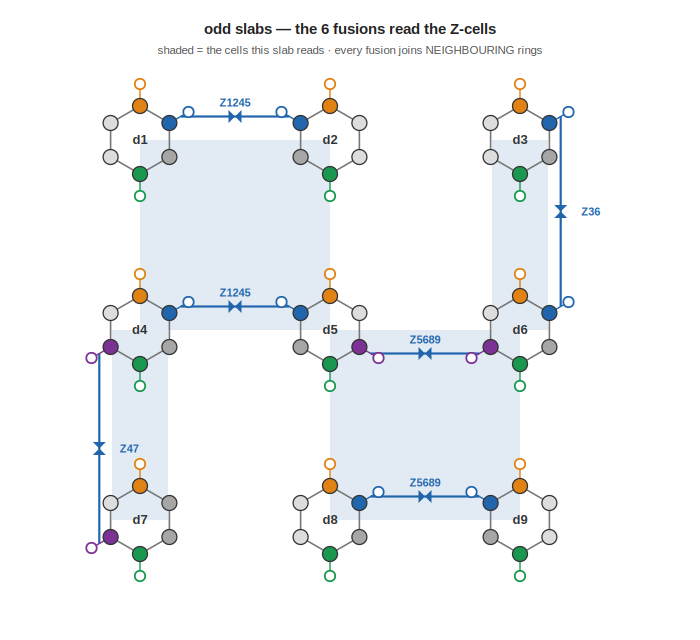

In [8]:
ZSHADE = [("Z1245", [1,2,4,5]), ("Z5689", [5,6,8,9]), ("Z47", [4,7]), ("Z36", [3,6])]
show_svg(diagramB(SPATIAL_ODD, "odd slabs — the 6 fusions read the Z-cells",
                  "shaded = the cells this slab reads · every fusion joins NEIGHBOURING rings",
                  "#2166ac", ZSHADE))

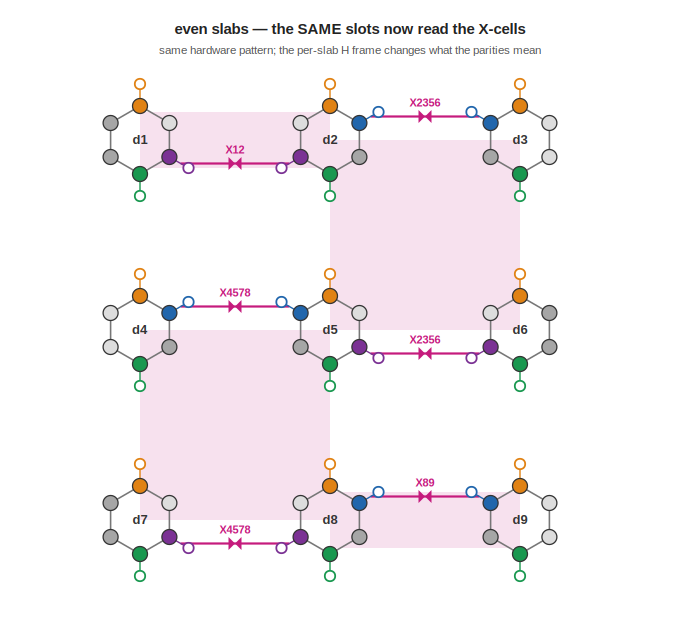

In [9]:
XSHADE = [("X2356", [2,3,5,6]), ("X4578", [4,5,7,8]), ("X12", [1,2]), ("X89", [8,9])]
show_svg(diagramB(SPATIAL_EVEN, "even slabs — the SAME slots now read the X-cells",
                  "same hardware pattern; the per-slab H frame changes what the parities mean",
                  "#c51b7d", XSHADE))

### Wait — where are the $(1,4)$ and $(2,5)$ fusions?

Look at `Z1245` above: only the pairs $(1,2)$ and $(4,5)$ are fused. A gate-based surface code
would couple an ancilla to **all four** qubits. Nothing is missing — this is the deepest
difference between the two machines:

* **The check is a *product* of pair readings.** The fusion at $(1,2)$ reads the parity $Z_1Z_2$;
  the fusion at $(4,5)$ reads $Z_4Z_5$; and
  $$ (Z_1Z_2)\cdot(Z_4Z_5) \;=\; Z_1Z_2Z_4Z_5 \;=\; \text{the stabilizer}. $$
  Any pairing that covers the support works: $\{(1,4),(2,5)\}$ would be an **equally valid
  choice** — and using *both* pairings is redundant, because the four pair operators multiply to
  the identity: $(Z_1Z_2)(Z_4Z_5)(Z_1Z_4)(Z_2Z_5) = \mathbb{1}$. All three facts verified live below.
* **The price of two-body readings.** An individual pair parity like $Z_1Z_2$ is *not* a
  stabilizer — it is a **gauge operator**: its outcome is genuinely random on the codespace (only
  the product is fixed), and measuring it temporarily scrambles the anticommuting $X$-cells
  (e.g. $X_2X_3X_5X_6$, which shares exactly one qubit with $Z_1Z_2$). That scrambling is *why*
  the $X$-cells are read on the alternate slabs — the half-layer offset is the code repairing its
  own gauge. This is a two-body gauge decomposition in the spirit of subsystem codes, and it is
  exactly what the FBQC paper means by *"checks are products of fusion outcomes"* (12 per bulk cell).
* **What replaces the "vertical" couplings.** The job the $(1,4)$/$(2,5)$ fusions would have done
  — tying the two pair readings to the *same moment* of the four worldlines — is done by the
  **recorded transport frame**: the temporal-fusion legs and pattern bits of the four worldlines
  enter the check's parity. The next section shows this bit by bit.

In [10]:
# verify all three claims on the code state |0_L>  (tableau; a pair parity Z_iZ_j is
# measured by the Bell-analyzer trick: CNOT(j→i) maps Z_i ↦ Z_iZ_j, read Z_i, undo the CNOT)
measure_pair!(t, i, j) = (cnot!(t, j, i); m = measure_z!(t, i); cnot!(t, j, i); m)
XST0 = [[2,3,5,6],[4,5,7,8],[1,2],[8,9]]                # the X-stabilizers fixing |0_L>
code_state() = (t = Tab(9); for st in XST0; project_xprod!(t, st); end; t)

r12 = Int[]; r45 = Int[]; pA = Int[]; pB = Int[]; pAll = Int[]
for trial in 1:200
    t = code_state()
    a = measure_pair!(t, 1, 2); b = measure_pair!(t, 4, 5)      # our pairing
    push!(r12, a); push!(r45, b); push!(pA, a ⊻ b)
    t = code_state()
    c = measure_pair!(t, 1, 4); d = measure_pair!(t, 2, 5)      # the alternative pairing
    push!(pB, c ⊻ d)
    t = code_state()                                             # all four pair readings at once
    w = measure_pair!(t, 1, 2) ⊻ measure_pair!(t, 4, 5) ⊻ measure_pair!(t, 1, 4) ⊻ measure_pair!(t, 2, 5)
    push!(pAll, w)
end
println("single pair readings random (gauge)?   Z1Z2: ", 0 < sum(r12) < 200, "   Z4Z5: ", 0 < sum(r45) < 200)
println("product over pairing (1,2),(4,5) always +1?  ", all(pA .== 0), "   ← the check")
println("product over pairing (1,4),(2,5) always +1?  ", all(pB .== 0), "   ← equally valid gauge choice")
println("XOR of ALL FOUR pair readings always 0?      ", all(pAll .== 0), "   ← adding them adds nothing")

single pair readings random (gauge)?   Z1Z2: true

   Z4Z5: true
product over pairing (1,2),(4,5) always +1?  true   ← the check
product over pairing (1,4),(2,5) always +1?  true   ← equally valid gauge choice
XOR of ALL FOUR pair readings always 0?      true   ← adding them adds nothing


## 5 · How rings tile space and time — and the references

**There is no store-then-measure loop.** The 2-D surface code foliated in time is a 3-D fusion
network, built and consumed on the fly. Two equivalent slicings of that same network, from the
primary literature:

* **Diagonal slicing** — Bartolucci *et al.*, *Fusion-based quantum computation*
  ([arXiv:2101.09310](https://arxiv.org/abs/2101.09310), Nat. Commun. **14**, 912 (2023)): 6-rings
  sit **two per unit cell at opposite corners** of a cubic lattice, arranged in layers
  perpendicular to the $(1,1,1)$ direction; quoting the paper, **"three qubits in each state fuse
  with the layer above, and three with the layer below."** Each check combines **12 fusion
  measurements**, $C_c = \prod_{f\in c}(XX)_f \prod_{e}(ZZ)_e$ — half the 4-star network's 24.
* **Temporal slicing** — Bombín *et al.*, *Interleaving: modular architectures for fault-tolerant
  photonic quantum computing* ([arXiv:2103.08612](https://arxiv.org/abs/2103.08612)): the same
  network partitioned into **2D slices perpendicular to the time axis**; each 6-ring is then a
  vertex of the cubic fusion graph with photons labelled $x^\pm,y^\pm,z^\pm$ — four spatial
  fusions in-slice, one fusion **forward in time** ($z^+$), one **backward** ($z^-$) — produced by
  resource-state generators and fibre delays. This is the slicing our slab implements.
* The underlying 3-D lattice: Raussendorf, Harrington, Goyal, *Topological fault-tolerance in
  cluster state quantum computation*, New J. Phys. **9**, 199 (2007).

"Moving the qubit to the next cycle" *is* the $z^+$ fusion of the current slice — there is no
feed-forward object anywhere. At $d{=}3$ the patch is boundary-dominated: our bulk qubit `d5`
fuses 4 of its 6 photons per slab (2 temporal + its 2 same-type cells; the paper's fully-fused
bulk ring appears at larger distance, where each qubit borders 4 same-type cells per slice pair).

**Space and time in one picture.** Left to right is space, bottom to top is time. Follow
one worldline: it enters a ring at $z^-$ (green fusion), threads through to $z^+$, and the *next*
green fusion carries it into the next slab's ring — while the blue/pink fusions on the way are the
check edges. Nothing else happens to it, ever:

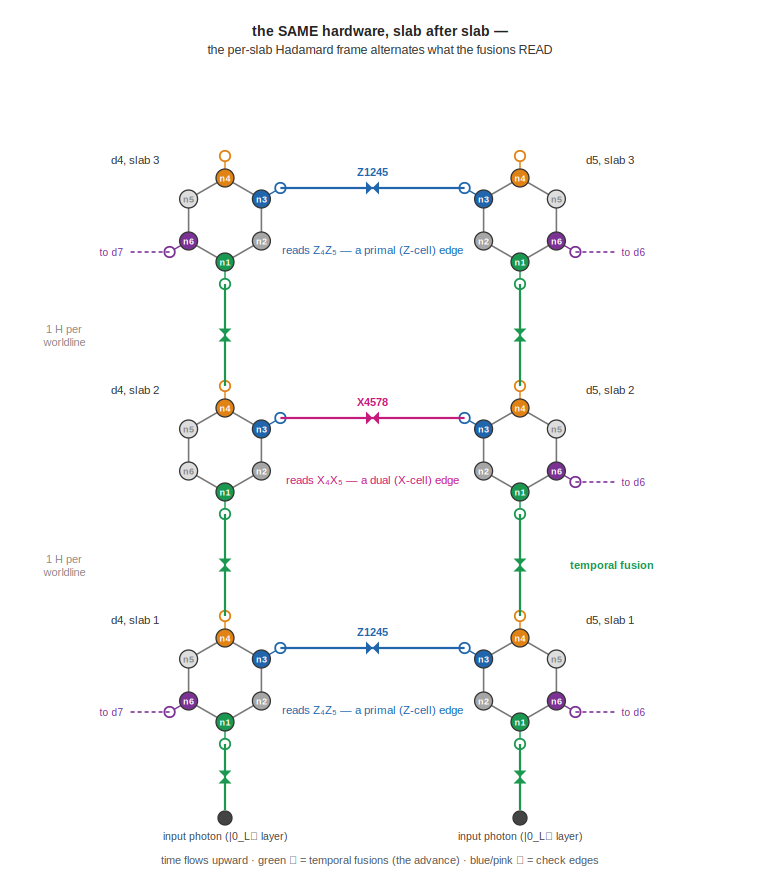

In [11]:
show_svg(diagramC())

And the whole $d{=}3$ patch, three slabs deep — nine rings per slab, six spatial fusions
within each slab, nine temporal fusions up to the next. This is the finite, boundary-carved cousin
of the papers' 3-D network (their Fig. 2, sliced the interleaving way):

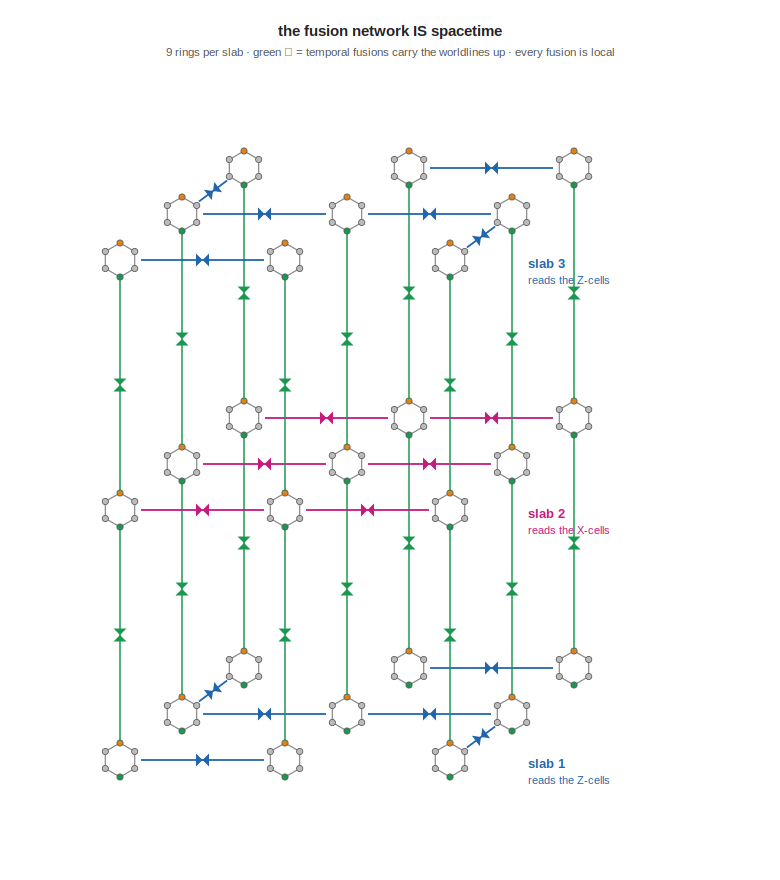

In [12]:
show_svg(diagramC2(SPATIAL_ODD, SPATIAL_EVEN))

## 6 · The machine — resource boxes and the slab

Below is the whole machine, annotated step by step. The discipline to watch for:

* `prep_ring!` and `prep_layer0!` are **resource boxes** — the *only* places a CZ appears (this is
  what the source delivers, pre-entangled);
* `slab!` is *one loop over rings* — deliver, fuse, house-keep — using **only** `fuse!` (a beam
  splitter) and single-photon measurements;
* three housekeeping moves recur — **prune**, **pad**, **retire** — explained in the comments and
  in the next diagram. Every measurement outcome lands in the flat record `rec`; the syndrome, the
  transport frame, and the logical are all read from `rec` *afterwards*.

In [13]:
const XSTAB = [[2,3,5,6],[4,5,7,8],[1,2],[8,9]]     # X-stabilizers (fix the |0_L> input)
const ZL9   = [1,2,3]                                  # the Z_L support (bottom row)
nname(t,i,k) = Symbol("t$(t)_r$(i)_n$(k)")             # ring NODE k of qubit i, slab t
lname(t,i,s) = Symbol("t$(t)_r$(i)_L$(s)")             # the LEAF sitting on slot s of that ring

# ══ RESOURCE BOX · the leafed 6-ring ═══════════════════════════════════════════
# Everything in here is what the SOURCE emits, pre-entangled: the only CZs in the
# whole notebook live in these boxes. One call = one resource state delivered.
function prep_ring!(r::Reg, t, i)
    for k in 1:6                                       # ① six ring photons, each born |+>
        addphoton!(r, nname(t,i,k))
    end
    for k in 1:6                                       # ② the six CZ edges of the RING —
        cz!(r, nname(t,i,k), nname(t,i, k==6 ? 1 : k+1))   #    n1–n2–n3–n4–n5–n6–n1 (a cycle)
    end
    addphoton!(r, lname(t,i,:n1))                      # ③ a LEAF on z− (n1): the photon the
    cz!(r, nname(t,i,1), lname(t,i,:n1))               #    TEMPORAL fusion will consume on arrival
    addphoton!(r, lname(t,i,:n4))                      # ④ a leaf on z+ (n4): consumed by the
    cz!(r, nname(t,i,4), lname(t,i,:n4))               #    NEXT slab's temporal fusion
    for sl in fused_slots(t, i)                        # ⑤ a leaf on each slot that fuses THIS
        k = parse(Int, string(sl)[2:2])                #    slab (n3 and/or n6, from the pairing
        addphoton!(r, lname(t,i,sl))                   #    table) — the source only grows leaves
        cz!(r, nname(t,i,k), lname(t,i,sl))            #    where a fusion is planned
    end
    track!(r)                                          # (bookkeeping: record the window size)
end

# ══ RESOURCE BOX · the input layer |0_L> ═══════════════════════════════════════
# Nine photons carrying the logical state INTO the network, each with the leaf
# its first temporal fusion will consume. (State preparation, not network ops.)
function prep_layer0!(r::Reg; err=:none, errslot=5, errafter=99)
    for i in 1:9; addphoton!(r, Symbol("W$i"); state=:zero); end   # |0>⁹ …
    for st in XSTAB                                                # … projected into |0_L>
        measure_pauli!(r, Dict(Symbol("W$i")=>'X' for i in st); force=0)
    end
    if errafter == -1 && err != :none                  # (a genuine INPUT error, injected on the
        err == :X ? x!(r, Symbol("W$errslot")) : z!(r, Symbol("W$errslot"))   #  bare photon,
    end                                                #  BEFORE its leaf exists)
    for i in 1:9                                       # the first flying leaves
        addphoton!(r, Symbol("LW$i")); cz!(r, Symbol("W$i"), Symbol("LW$i"))
    end
    return [Symbol("W$i") for i in 1:9], [Symbol("LW$i") for i in 1:9]
end

# ══ THE SLAB — deliver each ring, fuse it in. No gates, no stages. ═════════════
# Entering slab t we hold, per qubit i, exactly TWO photons from slab t−1:
#   W[i]  = the flying NODE  (last ring's z+ photon — it carries the worldline)
#   LW[i] = the flying LEAF  (pre-attached to it at the source)
# Everything else from slab t−1 has already been measured and dropped.
function slab!(r::Reg, t, W, LW, rec::Dict{String,Int})
    for i in 1:9
        # ─ STEP 1 · DELIVER ─ the source hands us qubit i's ring for this slab.
        prep_ring!(r, t, i)

        # ─ STEP 2 · TEMPORAL FUSION (one beam splitter) ─ the flying leaf LW[i]
        #   meets the new ring's z− leaf. Both leaves are consumed; the fusion
        #   Bell-MERGES the flying node W[i] with the ring's n1 — the worldline
        #   has ENTERED the new ring. The two click parities go on record: this
        #   one event is simultaneously the ADVANCE and a spacetime check edge.
        (mx, mz) = fuse!(r, LW[i], lname(t,i,:n1))
        rec["t$(t)_tf$(i)_x"] = mx; rec["t$(t)_tf$(i)_z"] = mz

        # ─ STEP 3 · RELEASE THE OLD PHOTON ─ W[i] has delivered its worldline;
        #   pattern-measure it in X (one cluster-wire hop: its outcome is a
        #   transport-frame bit) and DROP its site from the MPS. THIS is where
        #   each old photon leaves the sliding window — the register never grows.
        rec["t$(t)_xA$(i)"]   = measdrop!(r, W[i], 'X')

        # ─ STEP 4 · same for the z− node ─ n1 was Bell-merged with W[i]; its X
        #   outcome is the partner frame bit. The worldline now lives on the
        #   ring interior, walking the arm-1 spine n2 → n3 → n4.
        rec["t$(t)_xn1_$(i)"] = measdrop!(r, nname(t,i,1), 'X')

        # ─ STEP 5 · PRUNE ─ an arm-2 slot (n5/n6) with NO fusion this slab.
        #   If left in place it would close the ring into a loop, and a closed
        #   unfused loop MEASURES logical information (it decoheres the
        #   worldline — we verified this the hard way). A single-photon Z
        #   measurement DELETES that vertex from the cluster: this is how the
        #   code's boundary is carved out of uniform hardware. Outcome recorded
        #   (it enters detector/frame parities as a byproduct bit).
        for sl in prune_slots(t, i)
            k = parse(Int, string(sl)[2:2])
            rec["t$(t)_pr$(i)_$(sl)"] = measdrop!(r, nname(t,i,k), 'Z')
        end

        # ─ STEP 6 · PAD ─ an arm-1 slot (n2/n3) with no fusion sits ON the
        #   spine the worldline walks along, so it must NOT be deleted —
        #   X-measuring it turns it into a plain WIRE segment (one hop, one
        #   frame bit), keeping the n1→n4 path connected.
        for sl in pad_slots(t, i)
            k = parse(Int, string(sl)[2:2])
            rec["t$(t)_xn$(k)_$(i)"] = measdrop!(r, nname(t,i,k), 'X')
        end

        # ─ STEP 7 · SPATIAL (CHECK) FUSIONS ─ for every cell pairing whose
        #   SECOND partner is this ring (the first partner's leaf has been
        #   waiting), fuse the two slot leaves: one beam splitter per pairing.
        #   The ring NODES survive (only leaves are consumed). These outcomes
        #   ARE the check edges: on odd slabs the designated legs read Z_i Z_j,
        #   on even slabs (H frame) the same readings mean X_i X_j.
        for (f, (cell, a, sa, b, sb)) in enumerate(spatial(t))
            if b == i
                (mx2, mz2) = fuse!(r, lname(t,a,sa), lname(t,b,sb))
                rec["t$(t)_sf$(f)_$(cell)_x"] = mx2; rec["t$(t)_sf$(f)_$(cell)_z"] = mz2
            end
        end

        # ─ STEP 8 · RETIRE ─ ring a is "done" once every pairing touching it
        #   has fused (retire_after says when — e.g. ring 1 waits only for ring
        #   2; ring 3 waits for ring 6). Its fused-slot NODES — which stayed
        #   alive so their leaves could fuse — are now pattern-measured in X
        #   and dropped. After this, ALL that remains of qubit a in the machine
        #   is its z+ photon and that photon's leaf: the new flying photon.
        #   (See the ring-lifecycle diagram below.)
        for a in 1:i
            if retire_after(t, a) == i
                for sl in fused_slots(t, a)
                    k = parse(Int, string(sl)[2:2])
                    rec["t$(t)_xn$(k)_$(a)"] = measdrop!(r, nname(t,a,k), 'X')
                end
            end
        end
        track!(r)
    end
    # the nine flying (z+ node, leaf) pairs are the worldlines handed to slab t+1
    return [nname(t,i,4) for i in 1:9], [lname(t,i,:n4) for i in 1:9]
end

# ══ a full memory run ══════════════════════════════════════════════════════════
function run_memory(nslabs; err=:none, errslot=5, errafter=99, show=false)
    r = Reg(); rec = Dict{String,Int}(); PEAK[] = 0; reset_fuses!()
    W, LW = prep_layer0!(r; err=err, errslot=errslot, errafter=errafter)
    for t in 1:nslabs
        SHOW_FUSIONS[] = (show && t == 1)              # print slab 1's Bell readouts if asked
        W, LW = slab!(r, t, W, LW, rec)
        SHOW_FUSIONS[] = false
        if t == errafter && err != :none               # optionally hit a flying photon between slabs
            err == :X ? x!(r, W[errslot]) : z!(r, W[errslot])
        end
    end
    for i in 1:9                                       # detach the final leaves (nothing left to
        rec["fin_lz$(i)"] = measdrop!(r, LW[i], 'Z')   # fuse them with): Z-measure = remove, with
    end                                                # a recorded byproduct bit
    # after nslabs slabs every worldline carries frame H^nslabs, so Z_L reads as
    # ∏X (odd) or ∏Z (even) — take the exact expectation, then read destructively
    zl_exact = expect_pauli(r, Dict(W[i] => (isodd(nslabs) ? 'X' : 'Z') for i in ZL9))
    for i in 1:9
        rec["fin_wX$(i)"] = measdrop!(r, W[i], isodd(nslabs) ? 'X' : 'Z')
    end
    return rec, zl_exact
end
println("ring-native memory defined — post-prep operations: fuse! and single-photon measurements only.")

ring-native memory defined — post-prep operations: fuse! and single-photon measurements only.


### The life of one ring — prune, pad, retire, replace

The three housekeeping moves in pictures. Note what "retired" means for the entangled state: the
measured photons are *gone from the register* (their sites are contracted out of the MPS), but
their **outcomes remain in the record**, and the worldline plus every check correlation now flow
through the one surviving pair — the $z^+$ photon and its leaf. The register therefore holds at
most two partial layers of photons at any moment, no matter how many slabs we run.

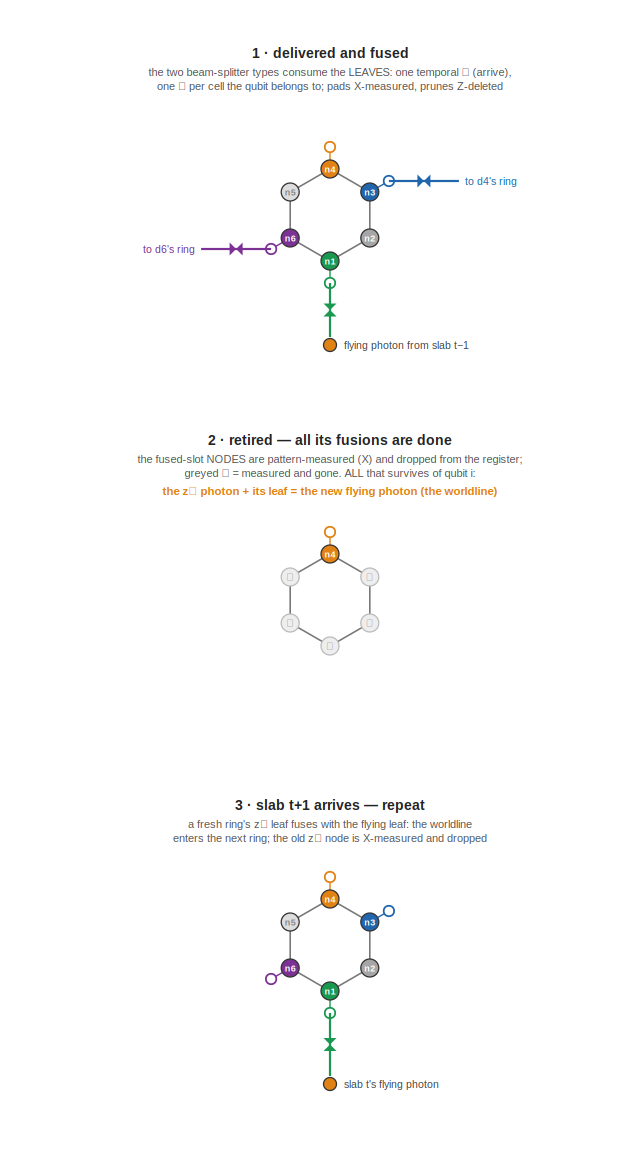

In [14]:
show_svg(diagramD())

## 7 · One slab, shown — 15 beam-splitter measurements

The full slab is **9 temporal + 6 spatial = 15 fusions**, each printed as a beam-splitter Bell
readout, interleaved only with single-photon pattern measurements. Watch the register stay bounded
— rings are delivered, fused, and retired on the fly.

In [15]:
rec, _ = run_memory(1; show=true)
println("\nfusions in the slab = ", FUSES[], "   ·   peak register = ", PEAK[], " photons",
        "   ·   record bits = ", length(rec))

    beam-splitter fusion LW1

⋈t1_r1_Ln1  →  Bell outcome Φ⁻   (X₁X₂=-1, Z₁Z₂=1)
    beam-splitter fusion LW2

⋈t1_r2_Ln1  →  Bell outcome Ψ⁻   (X₁X₂=-1, Z₁Z₂=-1)
    beam-splitter fusion t1_r1_Ln3

⋈t1_r2_Ln3  →  Bell outcome Ψ⁺   (X₁X₂=1, Z₁Z₂=-1)
    beam-splitter fusion LW3

⋈t1_r3_Ln1  →  Bell outcome Φ⁺   (X₁X₂=1, Z₁Z₂=1)
    beam-splitter fusion LW4⋈t1_r4_Ln1  →  Bell outcome Φ⁺   (X₁X₂=1, Z₁Z₂=1)


    beam-splitter fusion LW5⋈t1_r5_Ln1  →  Bell outcome Φ⁺   (X₁X₂=1, Z₁Z₂=1)
    beam-splitter fusion t1_r4_Ln3⋈t1_r5_Ln3  →  Bell outcome Ψ⁺   (X₁X₂=1, Z₁Z₂=-1)
    beam-splitter fusion LW6⋈t1_r6_Ln1  →  Bell outcome Φ⁺   (X₁X₂=1, Z₁Z₂=1)
    beam-splitter fusion t1_r5_Ln6⋈t1_r6_Ln6  →  Bell outcome Ψ⁻   (X₁X₂=-1, Z₁Z₂=-1)
    beam-splitter fusion t1_r3_Ln3

⋈t1_r6_Ln3  →  Bell outcome Ψ⁻   (X₁X₂=-1, Z₁Z₂=-1)
    beam-splitter fusion LW7⋈t1_r7_Ln1  →  Bell outcome Φ⁻   (X₁X₂=-1, Z₁Z₂=1)
    beam-splitter fusion t1_r4_Ln6⋈t1_r7_Ln6  →  Bell outcome Ψ⁺   (X₁X₂=1, Z₁Z₂=-1)
    beam-splitter fusion LW8⋈t1_r8_Ln1  →  Bell outcome Φ⁻   (X₁X₂=-1, Z₁Z₂=1)
    beam-splitter fusion LW9

⋈t1_r9_Ln1  →  Bell outcome Ψ⁻   (X₁X₂=-1, Z₁Z₂=-1)
    beam-splitter fusion t1_r8_Ln3⋈t1_r9_Ln3  →  Bell outcome Ψ⁺   (X₁X₂=1, Z₁Z₂=-1)

fusions in the slab = 15

   ·   peak register = 36 photons   ·   record bits = 102


## 8 · The syndrome is *in the record* — detectors as parity products

No photon is ever "read out as a check". The machine's entire output is the flat record of fusion
and pattern bits; the checks are **the deterministic GF(2) parities of that record** — found
exactly the way detector error models are built for real hardware: run the network clean many
times, and solve for the parity combinations that never vary.

Since every operation here is Clifford, the tableau twin (`chp_tableau.jl` — same slab, same
record names, verified against the MPS) does hundreds of such runs in seconds. The detector
compositions below were extracted that way offline; each one has the FBQC structure — the cell's
own fusion legs ($XX$ for arm-1 pairs, $ZZ$ for arm-2 pairs), completed by temporal-fusion legs
and pattern/prune bits (the recorded transport dressing):

In [16]:
# the 3-slab detector compositions: (const, record-bit names). Note the structure of e.g.
# Z5689: one of its fusions enters via its XX leg, the other via its ZZ leg — ∏(XX)·∏(ZZ).
const DET3 = Dict(
    "X12" => (0, ["t1_pr1_n6", "t1_pr2_n6", "t1_sf1_Z1245_z", "t1_tf1_z", "t1_tf2_z", "t1_xA1", "t1_xA2", "t1_xn1_1", "t1_xn1_2", "t1_xn3_1", "t1_xn3_2", "t2_pr1_n5", "t2_pr2_n5", "t2_sf5_X12_z", "t2_tf1_x", "t2_tf2_x", "t2_xn6_1", "t2_xn6_2"]),
    "X89" => (0, ["t1_pr8_n6", "t1_pr9_n6", "t1_sf4_Z5689_z", "t1_tf8_z", "t1_tf9_z", "t1_xA8", "t1_xA9", "t1_xn1_8", "t1_xn1_9", "t1_xn3_8", "t1_xn3_9", "t2_sf6_X89_x", "t2_tf8_x", "t2_tf9_x", "t2_xn2_8", "t2_xn2_9"]),
    "Z1245" => (0, ["fin_lz1", "fin_lz2", "fin_wX1", "fin_wX2", "t1_sf1_Z1245_x", "t1_sf2_Z1245_x", "t1_tf1_x", "t1_tf2_x", "t1_tf4_x", "t1_tf5_x", "t1_xn2_1", "t1_xn2_2", "t1_xn2_4", "t1_xn2_5", "t3_pr1_n5", "t3_pr2_n5", "t3_sf1_Z1245_x"]),
    "Z36" => (0, ["fin_lz3", "fin_lz6", "fin_wX3", "fin_wX6", "t1_sf6_Z36_x", "t1_tf3_x", "t1_tf6_x", "t1_xn2_3", "t1_xn2_6", "t3_pr3_n5", "t3_pr6_n5", "t3_sf6_Z36_x"]),
    "Z47" => (0, ["fin_lz4", "fin_lz7", "fin_wX4", "fin_wX7", "t1_pr4_n5", "t1_pr7_n5", "t1_sf5_Z47_z", "t1_tf4_x", "t1_tf7_x", "t1_xn6_4", "t1_xn6_7", "t3_sf5_Z47_z", "t3_xn2_4", "t3_xn2_7", "t3_xn6_4", "t3_xn6_7"]),
    "Z5689" => (0, ["fin_lz8", "fin_lz9", "fin_wX8", "fin_wX9", "t1_pr5_n5", "t1_pr6_n5", "t1_sf3_Z5689_z", "t1_sf4_Z5689_x", "t1_tf5_x", "t1_tf6_x", "t1_tf8_x", "t1_tf9_x", "t1_xn2_8", "t1_xn2_9", "t1_xn6_5", "t1_xn6_6", "t3_pr8_n5", "t3_pr9_n5", "t3_sf4_Z5689_x"]),
)
# the logical readout frame, fitted and verified on the exact engine (see §9):
const LOGI = (0, ["fin_lz1", "fin_lz2", "fin_lz3", "fin_wX1", "fin_wX2", "fin_wX3", "t1_pr1_n5", "t1_pr2_n5", "t1_pr3_n5", "t1_tf1_x", "t1_tf2_x", "t1_tf3_x", "t1_xn2_1", "t1_xn2_2", "t1_xn2_3", "t2_pr3_n6", "t2_sf1_X2356_z", "t2_sf5_X12_x", "t2_tf1_z", "t2_tf2_z", "t2_tf3_z", "t2_xA1", "t2_xA2", "t2_xA3", "t2_xn1_1", "t2_xn1_2", "t2_xn1_3", "t2_xn3_1", "t2_xn3_2", "t2_xn3_3", "t3_pr1_n5", "t3_pr2_n5", "t3_pr3_n5", "t3_tf1_x", "t3_tf2_x", "t3_tf3_x", "t3_xn2_1", "t3_xn2_2", "t3_xn2_3"])
detbit(rec, d) = reduce(⊻, (rec[b] for b in d[2]); init=d[1])
for c in sort(collect(keys(DET3)))
    own = count(b -> occursin("_$(c)_", b), DET3[c][2])
    println(rpad(c,6), ": ", length(DET3[c][2]), " record bits, ", own, " of them its own fusion legs")
end

X12   : 

18 record bits, 1 of them its own fusion legs
X89   : 16 record bits, 1 of them its own fusion legs
Z1245 : 17 record bits, 3 of them its own fusion legs
Z36   : 12 record bits, 2 of them its own fusion legs
Z47   : 16 record bits, 2 of them its own fusion legs
Z5689 : 19 record bits, 3 of them its own fusion legs


### Anatomy of one detector — from the $(m_x, m_z)$ clicks to a syndrome bit

Walk the whole chain once, concretely, for `Z1245`. Every `fuse!` returns its two beam-splitter
parities and files them in `rec` under readable names: `t1_sf1_Z1245_x` means *slab 1, spatial
fusion #1 (the $(1,2)$ pairing of cell `Z1245`), the $X_1X_2$ leg*; `..._z` is the same fusion's
$Z_1Z_2$ leg; `t1_tf4_x` is the $x$ leg of worldline 4's temporal fusion. Which leg carries the
cell is set by the slot (§4's Choi probe): $n3$ pairs read through their **$x$** leg, $n6$ pairs
through their **$z$** leg — the other leg of each fusion is a dual-graph edge.

The simplest (input-referenced) `Z1245` detector is a **10-bit parity** in three groups:

* `sf1_x ⊕ sf2_x` — the two pair readings $(Z_1Z_2)$ and $(Z_4Z_5)$: *the check itself*;
* `tf1_x ⊕ tf2_x ⊕ tf4_x ⊕ tf5_x` — the temporal-fusion legs of the four worldlines: each pair
  reading really measures the **ring photons'** $Z$'s, and these bits are the recorded frame
  relating each ring photon back to its incoming worldline;
* `xn2_1 ⊕ xn2_2 ⊕ xn2_4 ⊕ xn2_5` — the pad hops those four worldlines took on the ring spine.

The last two groups are the *transport dressing* — the recorded stand-in for the couplings a
gate-based ancilla would have provided (the "missing" vertical fusions of the previous section).
Drop them and the parity stops being deterministic:

In [17]:
# the input-referenced Z1245 detector (extracted offline by GF(2); verified here live)
Z1245_IN = (0, ["t1_sf1_Z1245_x", "t1_sf2_Z1245_x", "t1_tf1_x", "t1_tf2_x", "t1_tf4_x", "t1_tf5_x", "t1_xn2_1", "t1_xn2_2", "t1_xn2_4", "t1_xn2_5"])
own   = [b for b in Z1245_IN[2] if occursin("_Z1245_", b)]
dress = setdiff(Z1245_IN[2], own)
println("own fusion legs : ", join(own, " ⊕ "))
println("dressing        : ", join(dress, " ⊕ ")); println()

Random.seed!(21)
recs  = [chp_memory(3) for _ in 1:100]                                  # 100 clean runs
full  = [reduce(⊻, (r[b] for b in Z1245_IN[2]); init=Z1245_IN[1]) for r in recs]
bare  = [reduce(⊻, (r[b] for b in own); init=0) for r in recs]
recsE = [chp_memory(3; err=:X, errslot=5, errafter=-1) for _ in 1:50]   # X on d5 flips Z1245
fullE = [reduce(⊻, (r[b] for b in Z1245_IN[2]); init=Z1245_IN[1]) for r in recsE]
println("full 10-bit parity, clean:     always 0?  ", all(full .== 0), "      ← a DETECTOR")
println("own legs only (no dressing):   always 0?  ", all(bare .== 0), "   (", sum(bare), "/100 ones — random)")
println("full parity, input X on d5:    always 1?  ", all(fullE .== 1), "      ← the syndrome bit fires")

own fusion legs : t1_sf1_Z1245_x ⊕ t1_sf2_Z1245_x


dressing        : t1_tf1_x ⊕ t1_tf2_x ⊕ t1_tf4_x ⊕ t1_tf5_x ⊕ t1_xn2_1 ⊕ t1_xn2_2 ⊕ t1_xn2_4 ⊕ t1_xn2_5

full 10-bit parity, clean:     always 0?  

true      ← a DETECTOR
own legs only (no dressing):   always 0?  false   (64/100 ones — random)
full parity, input X on d5:    always 1?  true      ← the syndrome bit fires


**Live check on the tableau twin** — 200 clean runs: the record has a fixed number of
deterministic parities (the detector + gauge space), every baked detector reads 0 in every run,
and the same machine screens the error sweep of §10.

In [18]:
Random.seed!(7)
recs = [chp_memory(3) for _ in 1:200]
names = sort(collect(keys(recs[1])))
M = zeros(Int, length(recs), length(names))
for (t, rec) in enumerate(recs), (j, nm) in enumerate(names); M[t,j] = rec[nm]; end
basis, _ = affine_invariants(M)
okdet = all(all(detbit(rec, DET3[c]) == 0 for c in keys(DET3)) for rec in recs)
println("record bits: ", length(names), "   deterministic parities (invariants): ", length(basis))
println("all ", length(DET3), " baked detectors = 0 in all 200 clean runs: ", okdet)

record bits: 279

   deterministic parities (invariants): 80
all 6 baked detectors = 0 in all 200 clean runs: true


## 9 · The memory experiment — on the exact MPS

The `08` bar, met on the fusion network: a clean run gives **every detector = 0** and the logical
readout $+1$; an input error flips **exactly its own cells' detectors**; and a harmful error
($X$ on a $Z_L$-support qubit) flips the readout *and* is flagged by its fired detector — the
decoder's correction, sitting right there in the record.

The logical readout is itself a parity of the record: after 3 slabs every worldline carries frame
$H^3$, so $Z_L$ arrives as $\prod X$ on the bottom row; the destructive $X$-readout of `d1,d2,d3`
XORed with their recorded transport dressing (temporal-fusion legs, pattern, prune and two link
legs — 39 bits in all, `LOGI` of §8) equals the stored value. This identity was extracted from the
tableau twin's record-invariants and **cross-verified on 140 independent exact-MPS runs**.

### [1] Clean run — six silent detectors, logical readout +1

In [19]:
Random.seed!(31)
rec, zl = run_memory(3)
println("detectors: ", join(["$c=$(detbit(rec, DET3[c]))" for c in sort(collect(keys(DET3)))], "  "))
println("logical readout (39-bit record parity) = ", (-1)^detbit(rec, LOGI),
        "    exact |<Z_L>| pre-readout = ", round(abs(zl), digits=6))
println("peak register = ", PEAK[], " photons   fusions = ", FUSES[], " (= 3 slabs × 15)")

detectors: X12=0  X89=0  Z1245=0  Z36=0  Z47=0  Z5689=0


logical readout (39-bit record parity) = 1    exact |<Z_L>| pre-readout = 1.0
peak register = 36 photons   fusions = 45 (= 3 slabs × 15)


### [2] A bit-flip $X$ on the input `d5` photon — its two $Z$-cells fire, logical untouched

In [20]:
Random.seed!(32)
rec, zl = run_memory(3; err=:X, errslot=5, errafter=-1)
println("detectors: ", join(["$c=$(detbit(rec, DET3[c]))" for c in sort(collect(keys(DET3)))], "  "))
println("=> Z1245 and Z5689 fire — the two Z-cells containing d5; everything else silent")
println("logical readout = ", (-1)^detbit(rec, LOGI), "   (d5 ∉ Z_L support: +1, untouched)")

detectors: X12=0  X89=0  Z1245=1  Z36=0  Z47=0  Z5689=1


=> Z1245 and Z5689 fire — the two Z-cells containing d5; everything else silent
logical readout = 1   (d5 ∉ Z_L support: +1, untouched)


### [3] A phase-flip $Z$ on the input `d1` photon — its $X$-cell fires, logical untouched

In [21]:
Random.seed!(33)
rec, zl = run_memory(3; err=:Z, errslot=1, errafter=-1)
println("detectors: ", join(["$c=$(detbit(rec, DET3[c]))" for c in sort(collect(keys(DET3)))], "  "))
println("=> X12 fires — the X-cell containing d1")
println("logical readout = ", (-1)^detbit(rec, LOGI), "   (Z commutes with Z_L: +1)")

detectors: X12=1  X89=0  Z1245=0  Z36=0  Z47=0  Z5689=0


=> X12 fires — the X-cell containing d1
logical readout = 1   (Z commutes with Z_L: +1)


### [4] A bit-flip $X$ on the input `d1` photon — harmful, and the record knows

`d1` **is** in the $Z_L$ support: an uncorrected input $X$ flips the stored logical. The raw
readout comes back $-1$ — and `Z1245`, the fired detector, is exactly the flag a decoder would
use to correct it. Error, syndrome, and correction are all parities of the same record.

In [22]:
Random.seed!(34)
rec, zl = run_memory(3; err=:X, errslot=1, errafter=-1)
println("detectors: ", join(["$c=$(detbit(rec, DET3[c]))" for c in sort(collect(keys(DET3)))], "  "))
raw = (-1)^detbit(rec, LOGI)
println("raw logical readout = ", raw, "   fired detector Z1245 = ", detbit(rec, DET3["Z1245"]))
println("decoder-corrected readout = ", raw * (-1)^detbit(rec, DET3["Z1245"]), "   (recovered)")

detectors: X12=0  X89=0  Z1245=1  Z36=0  Z47=0  Z5689=0


raw logical readout = -1   fired detector Z1245 = 1
decoder-corrected readout = 1   (recovered)


## 10 · The error sweep, and the half-layer offset

The tableau twin screens **every error position**: each Pauli, on each probed photon, at each slab
boundary. Three structural facts of foliation appear by themselves:

* a physical $X$ on a flying photon is **gauge** ($X_v \equiv Z_{\mathrm{leaf}}$ by the cluster
  stabilizer of the photon–leaf edge) — harmless to the logical and invisible, as it should be;
* an error is detected when readings of its sector **bracket** it — the first/last windows are
  half-open (the standard boundary effect of foliated codes);
* the **weight-4 $X$-cells close against the readout layer** — they live on the *even* half-layers,
  offset from the $Z$-cells. At 2 slabs their detectors exist (below), and a phase flip between the
  last slab and the readout fires them.

In [23]:
# the 2-slab compositions include all four X-cells (they close against the readout):
const DET2 = Dict(
    "X12" => (0, ["fin_lz1", "fin_lz2", "fin_wX1", "fin_wX2", "t2_sf5_X12_z", "t2_xn2_1", "t2_xn2_2", "t2_xn6_1", "t2_xn6_2"]),
    "X2356" => (0, ["fin_lz2", "fin_lz3", "fin_wX2", "fin_wX3", "t2_pr2_n5", "t2_pr3_n5", "t2_sf1_X2356_x"]),
    "X4578" => (0, ["fin_lz4", "fin_lz5", "fin_wX4", "fin_wX5", "t2_pr4_n5", "t2_pr5_n5", "t2_sf3_X4578_x"]),
    "X89" => (0, ["fin_lz8", "fin_lz9", "fin_wX8", "fin_wX9", "t2_pr8_n5", "t2_pr9_n5", "t2_sf6_X89_x"]),
    "Z1245" => (0, ["t1_sf1_Z1245_x", "t1_sf2_Z1245_x", "t1_tf1_x", "t1_tf2_x", "t1_tf4_x", "t1_tf5_x", "t1_xn2_1", "t1_xn2_2", "t1_xn2_4", "t1_xn2_5"]),
    "Z36" => (0, ["t1_sf6_Z36_x", "t1_tf3_x", "t1_tf6_x", "t1_xn2_3", "t1_xn2_6"]),
    "Z47" => (0, ["t1_pr4_n5", "t1_pr7_n5", "t1_sf5_Z47_z", "t1_tf4_x", "t1_tf7_x", "t1_xn6_4", "t1_xn6_7"]),
    "Z5689" => (0, ["t1_pr5_n5", "t1_pr6_n5", "t1_sf3_Z5689_z", "t1_sf4_Z5689_x", "t1_tf5_x", "t1_tf6_x", "t1_tf8_x", "t1_tf9_x", "t1_xn2_8", "t1_xn2_9", "t1_xn6_5", "t1_xn6_6"]),
)
Random.seed!(8)
recs2 = [chp_memory(2) for _ in 1:200]
ok2 = all(all(detbit(rec, DET2[c]) == 0 for c in keys(DET2)) for rec in recs2)
println("2-slab: all ", length(DET2), " detectors (incl. X2356, X4578) = 0 in 200 clean runs: ", ok2)

# the sweep: input errors + flying-photon errors at every slab boundary (tableau, 40 runs each)
println("\nerror sweep (3-slab compositions; err on d-slot, 'input' = before slab 1):")
for (err, slot) in ((:X,5), (:X,1), (:Z,5), (:Z,1)), ea in (-1, 1, 2, 3)
    fires = String[]
    for c in sort(collect(keys(DET3)))
        vals = [detbit(chp_memory(3; err=err, errslot=slot, errafter=ea), DET3[c]) for _ in 1:12]
        all(vals .== 1) && push!(fires, c)
    end
    pos = ea == -1 ? "input " : "after slab $ea"
    println("  $err on d$slot, ", rpad(pos, 13), " → ", isempty(fires) ? "(silent)" : join(fires, ", "))
end
println("""\nreading the table: input X errors fire their Z-cells; Z errors in the H-window
(odd boundaries) act as code-X and fire Z-cells; physical X on flying photons is pure gauge;
half-open first/last windows are silent — the decoder's spacetime graph would connect these
readings across many slabs (that graph is nb6/nb8 territory).""")

2-slab: all 8

 detectors (incl. X2356, X4578) = 0 in 200 clean runs: true

error sweep (3-slab compositions; err on d-slot, 'input' = before slab 1):
  X on d5, 

input         → Z1245, Z5689
  X on d5, after slab 1 

 → (silent)
  X on d5, 

after slab 2  → (silent)
  X on d5, after slab 3 

...

 → (silent)
  Z on d1, 

input         → X12
  Z on d1, after slab 1 

 → (silent)
  Z on d1, 

after slab 2  → (silent)
  Z on d1, after slab 3 

 → Z1245

reading the table: input X errors fire their Z-cells; Z errors in the H-window
(odd boundaries) act as code-X and fire Z-cells; physical X on flying photons is pure gauge;
half-open first/last windows are silent — the decoder's spacetime graph would connect these
readings across many slabs (that graph is nb6/nb8 territory).


### The X-cells firing — a phase flip just before the readout (2 slabs)

In [24]:
Random.seed!(9)
fires = String[]
for c in sort(collect(keys(DET2)))
    vals = [detbit(chp_memory(2; err=:Z, errslot=5, errafter=2), DET2[c]) for _ in 1:12]
    all(vals .== 1) && push!(fires, c)
end
println("Z on d5 between the last slab and readout → fires: ", join(fires, ", "))
println("(the X-cell reading that straddles d5 — the dual sector, closed against the readout layer)")

Z on d5 between the last slab and readout → fires: X4578


(the X-cell reading that straddles d5 — the dual sector, closed against the readout layer)


## 10b · From the record to a decoder

The full pipeline, now end to end:

1. **The machine produces one thing**: the record `rec` — every fusion's $(m_x, m_z)$ clicks and
   every single-photon pattern bit, with nothing labelled "syndrome" anywhere.
2. **Detectors** are fixed parities of `rec` that are deterministic on a clean run (§8). Their
   values form the **syndrome vector** — here six bits per run.
3. **Each error mechanism flips a specific detector subset.** That map — error location →
   syndrome signature → effect on the logical readout — is the *detector error model*, and we can
   **self-calibrate** it by simulation, exactly as one does for real hardware: inject each error,
   record what fires and whether the logical readout parity flips.
4. **The decoder** inverts the map: observed syndrome → most likely error class → a *classical*
   correction XORed into the logical **readout** (never a correction to the state). On this small
   patch the lookup below *is* minimum-weight matching on the detector graph; at scale it becomes
   union-find/MWPM on the spacetime graph (built in `8.Scaling` / `6.Real-Time-Decoder`).

We calibrate and run it for the error channel that threatens the stored $Z_L$ memory — a bit-flip
on any one of the nine input photons. Note the two syndrome ambiguities and why they are harmless:
$\{Z1245\}$ is caused by $X$ on `d1` *or* `d2` — but both flip $Z_L$, so the correction is the
same; $\{Z5689\}$ means `d8` or `d9` — neither flips $Z_L$. The lattice does the bookkeeping.

In [25]:
# ---- self-calibrate the detector error model (tableau: each row = 12 runs) ----
Random.seed!(41)
cellnames = sort(collect(keys(DET3)))
SIG = Dict{Vector{String},Int}()                    # syndrome signature -> logical correction
println("error (input X)   syndrome signature      flips Z_L readout?")
for slot in 1:9
    recs = [chp_memory(3; err=:X, errslot=slot, errafter=-1) for _ in 1:12]
    fires = [c for c in cellnames if all(detbit(r, DET3[c]) == 1 for r in recs)]
    flips = [reduce(⊻, (r[b] for b in LOGI[2]); init=LOGI[1]) for r in recs]
    @assert all(flips .== flips[1])                 # the logical effect is deterministic
    SIG[fires] = flips[1]
    println("  X on d$slot          {", rpad(join(fires, ", "), 16), "}    ", flips[1] == 1)
end
SIG[String[]] = 0                                   # empty syndrome -> no correction
println("\ncalibrated: ", length(SIG), " syndrome signatures")

error (input X)   syndrome signature      flips Z_L readout?
  X on d1          {Z1245           

}    true
  X on d2          {

Z1245           }    true
  X on d3          {Z36             

}    true
  X on d4          {

Z1245, Z47      }    false
  X on d5          {Z1245, Z5689    

}    false
  X on d6          {

Z36, Z5689      }    false
  X on d7          {Z47             

}    false
  X on d8          {

Z5689           }    false
  X on d9          {Z5689           

}    false

calibrated: 8 syndrome signatures


**Run the decoder.** Random single input bit-flips, decoded from the record alone:
read the six detector bits, look up the calibrated correction, XOR it into the logical readout.

In [26]:
decode(fires) = get(SIG, fires, 0)        # lookup = min-weight matching on this small graph
Random.seed!(42)
nok = 0; N = 90
for trial in 1:N
    slot = rand(1:9)                                              # an X error strikes somewhere
    rec = chp_memory(3; err=:X, errslot=slot, errafter=-1)
    fires = [c for c in cellnames if detbit(rec, DET3[c]) == 1]   # the syndrome, from the record
    raw   = reduce(⊻, (rec[b] for b in LOGI[2]); init=LOGI[1])    # the raw logical readout parity
    nok  += (raw ⊻ decode(fires)) == 0                            # decoder-corrected readout
end
println("random single input-X errors, decoded from the record:  ", nok, "/", N, " logical readouts recovered")

random single input-X errors, decoded from the record:  90

/90 logical readouts recovered


And once on the **exact MPS** — a case not shown before ($X$ on `d3`, which *is* in the
$Z_L$ support, so the raw readout flips and the decoder must catch it via its `Z36` signature):

In [27]:
Random.seed!(43)
rec, zl = run_memory(3; err=:X, errslot=3, errafter=-1)
fires = [c for c in cellnames if detbit(rec, DET3[c]) == 1]
raw   = (-1)^reduce(⊻, (rec[b] for b in LOGI[2]); init=LOGI[1])
println("syndrome: {", join(fires, ", "), "}   raw readout = ", raw,
        "   decoder correction = ", decode(fires) == 1 ? "flip" : "none")
println("decoder-corrected readout = ", raw * (-1)^decode(fires), "   (memory recovered)")
println("\n(d=3 corrects any SINGLE input bit-flip; two simultaneous errors exceed the code")
println(" distance. Many-slab decoding uses the same detectors as a spacetime matching graph.)")

syndrome: {Z36

}   raw readout = -1   decoder correction = flip
decoder-corrected readout = 1   (memory recovered)

(d=3 corrects any SINGLE input bit-flip; two simultaneous errors exceed the code
 distance. Many-slab decoding uses the same detectors as a spacetime matching graph.)


## 11 · The fusion ledger

Per slab, for the whole $d{=}3$ patch: **9 temporal + 6 spatial = 15 beam-splitter fusions**, plus
single-photon pattern/prune measurements — and *nothing else*. Those 15 fusions simultaneously:

* carry all nine logical worldlines one step forward in time ($z^-$ fusions),
* generate the check edges (spatial fusions, one cell type per slab — the other type rides the
  same fusions' opposite legs and the next slab),
* leave the classical record from which syndrome, frame, and logical are read.


## 12 Fusion Success is 50% failure

Everything above assumed every beam splitter succeeds. Real linear optics does not: an unboosted
type-II fusion succeeds with probability **1/2** (the Calsamiglia–Lütkenhaus bound for linear-optical
Bell analysis). Our three-slab run performs 45 fusions — at 50% failure, the chance they *all*
succeed is $2^{-45}$. How can this scheme possibly be robust? Three facts change the picture
(all from [arXiv:2101.09310](https://arxiv.org/abs/2101.09310)):

1. **Failure is heralded and gentle.** A failed fusion does not lose the photons — the circuit
   degrades into *separable single-photon measurements* $Z_1, Z_2$: the $Z_1Z_2$ parity **is still
   recovered** as their product, only $X_1X_2$ is erased, and — quoting the paper — *"failed
   fusions produce pure quantum states."* You know exactly which parity is missing, and you can
   even *choose* which basis survives by reconfiguring the device (the paper's failure biasing).
2. **A heralded erasure is half an error.** Known-location losses are what erasure decoders eat
   for breakfast.
3. **The failure rate is a dial, not a constant**: boosting a fusion with $2^n\!-\!2$ ancilla
   photons reduces failure to $2^{-n}$ (50% → 25% → 12.5% …, Grice 2011; Ewert–van Loock 2014),
   and *encoding* the fusion qubits lifts the network's tolerance dramatically — the paper's
   (2,2)-Shor-encoded 6-ring network has a marginal **fusion-failure threshold of 43.2%**.

### Single failures in the network — absorbed

Because heralding = *the record bit is simply never created*, the machine knows exactly which
parities it lost, and everything downstream reads off which formulas survive. Two single-failure
experiments on the tableau twin (same wiring as the MPS):

* a failed **check fusion** ⇒ that cell's detector is *heralded-unavailable* this round — a
  missing check, nothing more; every other detector still reads 0 and the logical is untouched;
* a failed **temporal fusion** ⇒ one worldline is cut — yet for the stored $|0_L\rangle$ **all
  three logical row-representatives stay evaluable and deterministic**: the cut qubit's
  $Z$-information is redundantly encoded in its cells ($Z_1 \equiv Z_2Z_4Z_5$ on the codespace),
  the replacement chain starts in a deterministic state, and the surviving $ZZ$ legs stitch the
  identity back together. The record reroutes *by itself*.

### What boosting would change here — and what it wouldn't

Boosting is worth being precise about, because it changes **much less of this notebook than you
might expect**. A Grice / Ewert–van Loock boosted fusion injects an **ancillary Bell pair** (or a
larger ancilla state) into the *same* beam-splitter network that performs the fusion, with more
detectors; $2^n\!-\!2$ ancilla photons raise the success probability to $1-2^{-n}$. The ancillas
are detected — consumed — whether the fusion succeeds or not. Consequences, piece by piece:

* **The 6-ring resource state: unchanged.** Boosting lives *inside the fusion device*, not in the
  network. Same six photons, same CZ cycle.
* **The leaves: unchanged in number.** Each ring still contributes exactly one leaf per fusion.
  What the source must *additionally* deliver is one ancilla Bell pair (or more) **per fusion
  attempt** — a new demand on the resource-state factory, not on the rings. (It is *encoded*
  fusion, below, that multiplies the leaves.)
* **`fuse!`: same success branch, new wrapper.** On success the boosted device projects onto the
  Bell basis exactly as before — same $(m_x, m_z)$, same record keys, same detectors, same
  logical identities. All that changes is the *rate*: the failure branch fires with $2^{-n}$
  instead of $\tfrac12$ (and the failure mode itself — separable $Z$'s, heralded — is the same
  model the FBQC paper uses at every boost level). At the qubit level, boosting is a Bernoulli
  dial plus an ancilla budget:

**The catch — ancillas can be lost.** Every extra photon must *arrive*: a boosted fusion
passes $2^n$ photons through the device, so with per-photon transmission $\eta$ the whole fusion
is erased with probability $1-\eta^{2^n}(1-2^{-n})$ — boosting trades failure for loss
sensitivity, and there is an **optimal boost level** for a given $\eta$.

### Encoded Fusion

**The upgrade that *does* change the resource states.** The FBQC paper's
strongest numbers come from replacing each fusion *qubit* by a small code block — e.g. a
(2,2)-Shor encoding, four photons per block. In our language every **leaf becomes a four-photon
block** (a 6-ring's photon count goes 6 → 24), and one *logical* fusion becomes **four physical
fusions**, one per photon pair across the two blocks. A physical failure or lost photon is then an
erasure *inside* the encoded fusion, correctable from the surviving pairs — that is how the 6-ring
network's marginal failure threshold reaches **43.2%**, comfortably above a single boost stage's
25%. Everything stays Clifford, so this machine could simulate it — the ring constructor would
grow blocks instead of leaves and `fuse!` would become a transversal loop with majority logic —
a natural next notebook, deferred. Failure-basis *biasing*, likewise, is a per-device dial (choose
which parity survives) requiring no change to the rings at all.

### Putting it together — so is this fault tolerance?

Almost every ingredient is now on the table; here is why **both** upgrades are needed, and what
else the sentence "fault-tolerant error correction" quietly assumes. The arithmetic (numbers from
[arXiv:2101.09310](https://arxiv.org/abs/2101.09310)):

| scheme | $p_\mathrm{fail}$ achieved | threshold it must beat | verdict |
|---|---|---|---|
| raw linear optics | 50% | < 25% (bare network) | ✗ far above |
| boosting alone (1 stage) | 25% | < 25% (bare network) | ✗ sits *at* threshold — no margin |
| encoding alone, unboosted | 50% | 43.2% (encoded 6-ring) | ✗ still above, marginally |
| **encoding + 1 boost stage** | **25%** | **43.2%** | ✓ below, with margin to spare |

The *margin* in the last row matters: 43.2% is a **marginal** threshold, computed with failure as
the only noise. A real machine must sit below a threshold **surface** jointly in (fusion failure,
photon loss, Pauli error) — the margin left after failure is what gets spent on loss, the actually
hard engineering number (and why our ladder table showed boosting stops paying at $n\approx2$–$3$
for realistic $\eta$).

**Three layers of protection, at three scales:**

1. **Boosting — device level.** Reduces the *rate* of failures: $2^n\!-\!2$ ancilla photons per
   beam splitter give $p_\mathrm{fail}=2^{-n}$. Costs photons per fusion → more loss exposure.
2. **Encoding — fusion level.** Makes the failures that still happen *correctable locally*: each
   leaf → a 4-photon block, one logical fusion = 4 physical fusions, and a failed or lost physical
   fusion is an erasure fixed *inside* the logical fusion by the surviving three.
3. **Distance — network level.** Whatever leaks through both layers becomes ordinary heralded
   erasure + Pauli noise on the code, and *this* is where "below threshold" pays: logical error
   falls exponentially in $d$. Our own $d{=}3$ sweep is the cautionary tale — even at the boosted
   25% the tiny patch survived only ~33% of runs. Thresholds are asymptotic promises; the bare
   network's marginal numbers (11.98% erasure, 1.07% Pauli) are all "$d\to\infty$" statements.

So: **yes — encoded fusion with boosted beam splitters, run at sufficient distance, on a hardware
budget whose residual loss and Pauli rates fit inside the leftover margin, is fault-tolerant error
correction.** Every clause in that sentence is load-bearing.

One last scope note: what this buys directly is a fault-tolerant **memory** and — by changing
fusion patterns between patches — the fusion-network analogue of lattice surgery, i.e. the full
Clifford layer. Universal *computation* needs one more storey: magic-state preparation and
distillation, built from the same rings and fusions (the
`4.Magic-states` thread of this series, in photonic dress).

*References: Calsamiglia & Lütkenhaus, App. Phys. B **72**, 67 (2001) (the 50% bound); Grice,
PRA **84**, 042331 (2011) and Ewert & van Loock, PRL **113**, 140403 (2014) (boosted Bell
analysis); Bartolucci et al., [arXiv:2101.09310](https://arxiv.org/abs/2101.09310) (failure model,
biasing, thresholds); [arXiv:2403.14811](https://arxiv.org/abs/2403.14811) (encoded-fusion loss
thresholds).*